# Analisis de Desigualdad Laboral de Genero — ENOE 2025 4T

**Objetivo:** Tres modelos de aprendizaje automatico orientados a un dashboard interactivo sobre brecha salarial y participacion laboral femenina en Mexico.

| Modelo | Tipo | Pregunta |
|--------|------|-----------|
| M1 | Clasificacion | ¿Participa una mujer en el mercado laboral? |
| M2 | Regresion | ¿Cuanto gana una persona y cuanto pierde por ser mujer? |
| M3 | Clasificacion | ¿Tiene empleo informal? |

**Archivos requeridos** (descargar de https://www.inegi.org.mx/programas/enoe/15ymas/):
- `sdem_enoe_2025_4t.csv`
- `coe1_enoe_2025_4t.csv`
- `coe2_enoe_2025_4t.csv`

## 0. Instalacion de dependencias

In [3]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn lightgbm joblib

## 1. Imports y configuracion

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
OUTPUT_DIR   = 'artefactos_dashboard'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Entorno listo.')

Entorno listo.


## 2. Carga de datos

In [5]:
PATH_SDEM = 'conjunto_de_datos_sdem_enoe_2025_4t.csv'
PATH_COE1 = 'conjunto_de_datos_coe1_enoe_2025_4t.csv'
PATH_COE2 = 'conjunto_de_datos_coe2_enoe_2025_4t.csv'

RK = dict(encoding='latin-1', low_memory=False)

sdem = pd.read_csv(PATH_SDEM, **RK)
coe1 = pd.read_csv(PATH_COE1, **RK)
coe2 = pd.read_csv(PATH_COE2, **RK)

for nombre, df_ in [('sdem', sdem), ('coe1', coe1), ('coe2', coe2)]:
    df_.columns = df_.columns.str.strip().str.lower()

print(f'sdem : {sdem.shape}')
print(f'coe1 : {coe1.shape}')
print(f'coe2 : {coe2.shape}')

sdem : (419038, 115)
coe1 : (344166, 174)
coe2 : (344166, 84)


## 3. Union de tablas

In [6]:
LLAVE = ['cd_a', 'cve_ent', 'con', 'upm', 'd_sem', 'n_pro_viv', 'v_sel', 'n_hog', 'n_ren']

# Forzar enteros en la llave de las tres tablas para garantizar el join
for df_ in [sdem, coe1, coe2]:
    for col in LLAVE:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors='coerce')

# Solo columnas COE2 que se usaran en el Modelo 2
COLS_COE2 = LLAVE + ['p6b2', 'p6c', 'p6d', 'p6b1']
COLS_COE2 = [c for c in COLS_COE2 if c in coe2.columns]

df = sdem.merge(coe1, on=LLAVE, how='left', suffixes=('', '_c1'))
df = df.merge(coe2[COLS_COE2], on=LLAVE, how='left')

# Eliminar columnas duplicadas del merge con coe1
df.drop(columns=[c for c in df.columns if c.endswith('_c1')], inplace=True)

print(f'Dataset unificado: {df.shape}')
print(f'p6c no nulos: {df["p6c"].notna().sum():,}' if 'p6c' in df.columns else 'p6c no disponible')

Dataset unificado: (419038, 272)
p6c no nulos: 344,166


## 4. Seleccion de variables y conversion de tipos

**Decisiones de encoding justificadas:**

- `niv_ins` (instruccion): ordinal 1→4, jerarquia educativa clara → `OrdinalEncoder`
- `t_loc_tri` (tamaño localidad): ordinal inverso (1=grande, 4=rural) → `OrdinalEncoder`
- `scian` (sector economico): 20 categorias nominales sin orden → `TargetEncoder` (OneHot generaria 20 columnas binarias que GBM y LGBM manejan peor que un encoding denso; con 118k filas el TargetEncoder es estable)
- `pos_ocu` (posicion en ocupacion): 4 categorias nominales, pocas → `OneHotEncoder` via TargetEncoder
- `e_con` (estado conyugal): 5 categorias nominales → `TargetEncoder`
- `cve_ent` (entidad): 32 categorias nominales → `TargetEncoder` (OneHot daria 32 dummies; con GBM/LGBM el target encoding es mas eficiente y no genera multicolinealidad)
- `ur` (urbano/rural): binaria → numerica directa

In [7]:
# Columnas numericas continuas
COLS_NUM = ['eda', 'anios_esc', 'hrsocup', 'ingocup', 'n_hij', 'fac_tri']

# Columnas categoricas ordinales (tienen jerarquia intrinseca)
COLS_ORD = ['niv_ins', 't_loc_tri']

# Columnas categoricas nominales (sin orden, se aplicara TargetEncoder en pipeline)
COLS_NOM = ['scian', 'pos_ocu', 'e_con', 'cve_ent']

# Columnas binarias o de clasificacion ENOE
COLS_BIN = ['sex', 'ur', 'clase1', 'clase2', 'emp_ppal',
            'seg_soc', 'sub_o', 'remune2c', 'pre_asa']

# Columnas COE2
COLS_COE2_VARS = ['p6b2', 'p6c', 'p6d', 'p6b1']

TODAS = COLS_NUM + COLS_ORD + COLS_NOM + COLS_BIN + COLS_COE2_VARS
TODAS = [c for c in TODAS if c in df.columns]

raw = df[TODAS].copy()

# Convertir todo a numerico
for col in TODAS:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Reemplazar codigos de no respuesta por NaN
CODIGOS_NULOS = {
    'eda'    : [97, 98, 99],
    'anios_esc': [99],
    'n_hij'  : [99],
    'hrsocup': [999],
    'ingocup': [999998, 999999],
    'niv_ins': [5, 9],
    'e_con'  : [9],
    'scian'  : [0, 21],
    'pos_ocu': [0, 5],
    'seg_soc': [3],
    'p6c'    : [9],
    'p6d'    : [9],
    'p6b1'   : [9],
    'pre_asa': [0],
    'remune2c': [0],
}
for col, vals in CODIGOS_NULOS.items():
    if col in raw.columns:
        raw[col] = raw[col].replace(vals, np.nan)

# Filtro de poblacion >= 15 anios
raw = raw[raw['eda'] >= 15].copy()

# Variables derivadas de genero
raw['es_mujer']          = (raw['sex'] == 2).astype(int)
raw['participa_laboral'] = (raw['clase1'] == 1).astype(int)
raw['es_ocupado']        = (raw['clase2'] == 1).astype(int)
raw['es_formal']         = (raw['emp_ppal'] == 2).astype(int)

print(f'Poblacion >= 15 anios: {len(raw):,}')
print(f'Mujeres : {raw["es_mujer"].sum():,}')
print(f'Ocupados: {raw["es_ocupado"].sum():,}')

Poblacion >= 15 anios: 323,737
Mujeres : 171,501
Ocupados: 190,069


# 4.1 Estandarizacion de medianas

In [8]:
# Filtrar solo población ocupada con ingresos válidos
df_ocup = raw[(raw['es_ocupado'] == 1) & (raw['ingocup'] > 0)].copy()

In [9]:
# Cálculo de Medianas por Género
ing_mediano_m = df_ocup[df_ocup['es_mujer'] == 1]['ingocup'].median()
ing_mediano_h = df_ocup[df_ocup['es_mujer'] == 0]['ingocup'].median()
brecha_mediana = (1 - (ing_mediano_m / ing_mediano_h)) * 100

In [10]:
print("RESULTADOS FINALES PARA DASHBOARD")
print("-" * 35)
print(f"Ingreso Mediano Mujeres: ${ing_mediano_m:,.2f}")
print(f"Ingreso Mediano Hombres: ${ing_mediano_h:,.2f}")
print(f"Brecha Salarial (Basado en Mediana): {brecha_mediana:.1f}%")
print("\nNota: Esta cifra es la más robusta estadísticamente y es la que se presenta en el Dashboard.")

RESULTADOS FINALES PARA DASHBOARD
-----------------------------------
Ingreso Mediano Mujeres: $8,170.00
Ingreso Mediano Hombres: $10,320.00
Brecha Salarial (Basado en Mediana): 20.8%

Nota: Esta cifra es la más robusta estadísticamente y es la que se presenta en el Dashboard.


## 5. Analisis de valores faltantes

Se evalua el porcentaje de missing **antes** de cualquier imputacion para decidir si una variable es utilizable.

In [11]:
VARS_ANALISIS = [
    'eda', 'anios_esc', 'niv_ins', 'e_con', 'n_hij', 'hrsocup', 'ingocup',
    'scian', 'pos_ocu', 't_loc_tri', 'ur', 'cve_ent', 'es_mujer',
    'participa_laboral', 'es_formal', 'p6b2', 'p6c', 'p6d', 'p6b1',
    'seg_soc', 'pre_asa', 'remune2c'
]
VARS_ANALISIS = [v for v in VARS_ANALISIS if v in raw.columns]

missing = pd.DataFrame({
    'n_nulos' : raw[VARS_ANALISIS].isnull().sum(),
    'pct_nulo': (raw[VARS_ANALISIS].isnull().sum() / len(raw) * 100).round(2)
}).sort_values('pct_nulo', ascending=False)

print('Porcentaje de valores faltantes por variable:')
display(missing)

# Umbral: variables con >60% de missing no se usaran en modelos
VARS_EXCLUIR = missing[missing['pct_nulo'] > 60].index.tolist()
print(f'\nVariables excluidas por >60% missing: {VARS_EXCLUIR}')

Porcentaje de valores faltantes por variable:


,n_nulos,pct_nulo
p6c,277223,85.6300
p6b2,202823,62.6500
pre_asa,189121,58.4200
remune2c,189121,58.4200
n_hij,152248,47.0300
p6b1,141871,43.8200
p6d,135396,41.8200
scian,135187,41.7600
pos_ocu,133668,41.2900
seg_soc,1728,0.5300



Variables excluidas por >60% missing: ['p6c', 'p6b2']


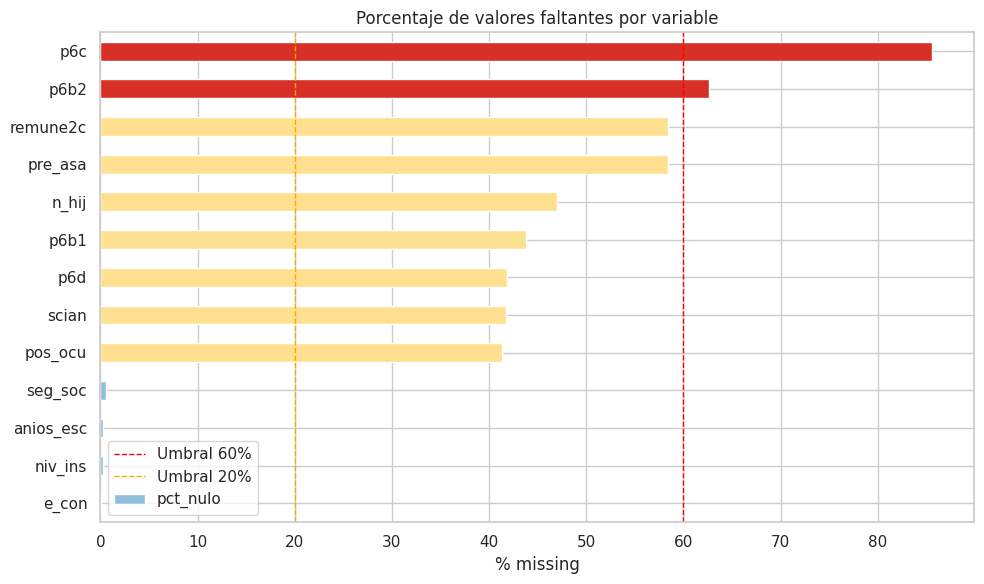

In [12]:
# Visualizacion de missing
fig, ax = plt.subplots(figsize=(10, 6))
missing_plot = missing[missing['pct_nulo'] > 0]
colores = ['#d73027' if p > 60 else '#fee090' if p > 20 else '#91bfdb'
           for p in missing_plot['pct_nulo']]
missing_plot['pct_nulo'].sort_values().plot(
    kind='barh', ax=ax, color=colores[::-1], edgecolor='white'
)
ax.axvline(x=60, color='red', linestyle='--', linewidth=1, label='Umbral 60%')
ax.axvline(x=20, color='orange', linestyle='--', linewidth=1, label='Umbral 20%')
ax.set_title('Porcentaje de valores faltantes por variable')
ax.set_xlabel('% missing')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/missing_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EDA — Desigualdad de genero

In [13]:
# Estadisticas clave por sexo
resumen_genero = raw.groupby('es_mujer').agg(
    n                  = ('eda', 'count'),
    tasa_participacion = ('participa_laboral', 'mean'),
    edad_mediana       = ('eda', 'median'),
    escolaridad_media  = ('anios_esc', 'mean'),
).rename(index={0: 'Hombre', 1: 'Mujer'})
resumen_genero['tasa_participacion'] = (resumen_genero['tasa_participacion'] * 100).round(2)
resumen_genero['escolaridad_media']  = resumen_genero['escolaridad_media'].round(2)
display(resumen_genero)

,n,tasa_participacion,edad_mediana,escolaridad_media
es_mujer,,,,
Hombre,152236,74.4800,40.0000,10.4100
Mujer,171501,47.5900,41.0000,10.2400


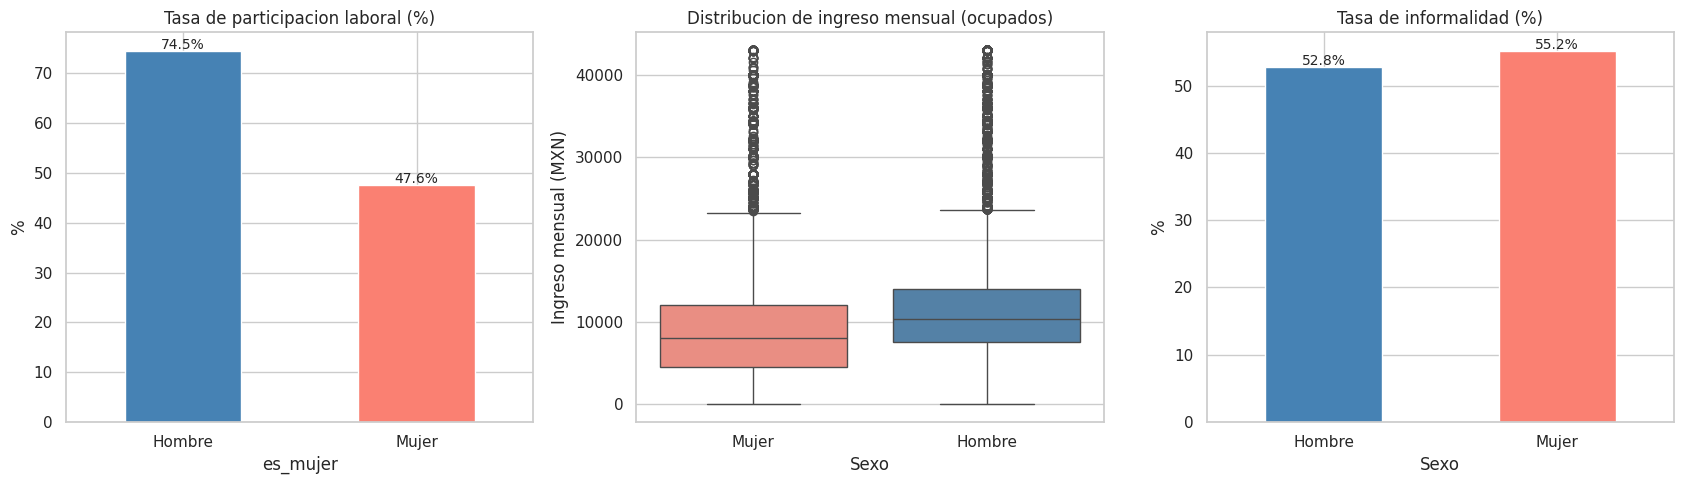

In [14]:
ocupados = raw[(raw['es_ocupado'] == 1) & (raw['ingocup'] > 0)].copy()
ocupados['Sexo'] = ocupados['es_mujer'].map({0: 'Hombre', 1: 'Mujer'})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Participacion laboral
part = raw.groupby('es_mujer')['participa_laboral'].mean().mul(100).rename({0:'Hombre',1:'Mujer'})
part.plot(kind='bar', ax=axes[0], color=['steelblue','salmon'], edgecolor='white', rot=0)
axes[0].set_title('Tasa de participacion laboral (%)')
axes[0].set_ylabel('%')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontsize=10)

# Distribucion de ingreso
p99 = ocupados['ingocup'].quantile(0.99)
sns.boxplot(
    data=ocupados[ocupados['ingocup'] <= p99],
    x='Sexo', y='ingocup', ax=axes[1],
    palette={'Hombre':'steelblue','Mujer':'salmon'}
)
axes[1].set_title('Distribucion de ingreso mensual (ocupados)')
axes[1].set_ylabel('Ingreso mensual (MXN)')

# Tasa de informalidad
inf = ocupados.groupby('Sexo')['es_formal'].apply(lambda x: (1-x.mean())*100).round(2)
inf.plot(kind='bar', ax=axes[2], color=['steelblue','salmon'], edgecolor='white', rot=0)
axes[2].set_title('Tasa de informalidad (%)')
axes[2].set_ylabel('%')
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_desigualdad.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Participacion femenina por entidad -> CSV para dashboard
part_ent = (
    raw[raw['es_mujer'] == 1]
    .groupby('cve_ent')['participa_laboral']
    .mean().mul(100).round(2)
    .reset_index()
    .rename(columns={'cve_ent':'entidad','participa_laboral':'tasa_participacion_femenina'})
    .sort_values('tasa_participacion_femenina')
)
display(part_ent)
part_ent.to_csv(f'{OUTPUT_DIR}/participacion_femenina_por_entidad.csv', index=False)

# Brecha salarial bruta por entidad -> CSV para dashboard
brecha_bruta = (
    ocupados.groupby(['cve_ent','Sexo'])['ingocup']
    .median().unstack('Sexo').dropna()
    .assign(brecha_pct=lambda x: ((x['Hombre']-x['Mujer'])/x['Hombre']*100).round(2))
    .reset_index()
    .rename(columns={'cve_ent':'entidad'})
    .sort_values('brecha_pct', ascending=False)
)
display(brecha_bruta.head(10))
brecha_bruta.to_csv(f'{OUTPUT_DIR}/brecha_salarial_bruta_por_entidad.csv', index=False)

,entidad,tasa_participacion_femenina
29,30,40.1600
6,7,40.7500
14,15,42.6500
31,32,43.0300
0,1,43.3800
13,14,44.9100
26,27,45.1400
27,28,45.4700
23,24,45.8500
16,17,46.0400


Sexo,entidad,Hombre,Mujer,brecha_pct
28,29,8170.0000,5375.0000,34.2100
19,20,8600.0000,6020.0000,30.0000
30,31,9890.0000,7000.0000,29.2200
12,13,9675.0000,6880.0000,28.8900
5,6,12000.0000,8600.0000,28.3300
22,23,12040.0000,9000.0000,25.2500
11,12,8600.0000,6450.0000,25.0000
10,11,10320.0000,7740.0000,25.0000
16,17,8000.0000,6000.0000,25.0000
20,21,8600.0000,6450.0000,25.0000


## 7. Modelo 1 — Participacion laboral femenina (clasificacion)

**Poblacion:** Mujeres >= 15 años.
**Target:** `participa_laboral` (1=PEA, 0=PNEA).
**Preprocesamiento dentro de Pipeline:** sin data leakage.

In [16]:
# Variables disponibles para M1 (sin variables de empleo: solo demograficas)
FEATS_M1_NUM = [c for c in ['eda', 'anios_esc', 'n_hij'] if c not in VARS_EXCLUIR]
FEATS_M1_ORD = [c for c in ['niv_ins', 't_loc_tri'] if c not in VARS_EXCLUIR]
FEATS_M1_NOM = [c for c in ['e_con', 'cve_ent'] if c not in VARS_EXCLUIR]
FEATS_M1_BIN = [c for c in ['ur'] if c not in VARS_EXCLUIR]

FEATS_M1 = FEATS_M1_NUM + FEATS_M1_ORD + FEATS_M1_NOM + FEATS_M1_BIN
TARGET_M1 = 'participa_laboral'

df_m1 = raw[raw['es_mujer'] == 1][FEATS_M1 + [TARGET_M1]].copy()
# Eliminar filas donde el target es nulo
df_m1 = df_m1.dropna(subset=[TARGET_M1])

print(f'Dataset M1: {df_m1.shape}')
print(f'Missing por variable:')
print((df_m1.isnull().sum() / len(df_m1) * 100).round(2).sort_values(ascending=False))
print(f'\nBalance del target:')
print(df_m1[TARGET_M1].value_counts(normalize=True).mul(100).round(2))

Dataset M1: (171501, 9)
Missing por variable:
anios_esc           0.2700
niv_ins             0.2000
e_con               0.0200
n_hij               0.0100
eda                 0.0000
t_loc_tri           0.0000
cve_ent             0.0000
ur                  0.0000
participa_laboral   0.0000
dtype: float64

Balance del target:
participa_laboral
0   52.4100
1   47.5900
Name: proportion, dtype: float64


In [17]:
X_m1 = df_m1[FEATS_M1]
y_m1 = df_m1[TARGET_M1].values

X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1, y_m1, test_size=0.2, random_state=RANDOM_STATE, stratify=y_m1
)
print(f'Train: {X_train_m1.shape} | Test: {X_test_m1.shape}')

# Preprocesador con ColumnTransformer
# Numericas: imputa mediana + escala
# Ordinales: imputa mediana + ordinal (respetan jerarquia)
# Nominales: imputa moda + target encoding (categorias con muchos niveles)
# Binarias: imputa mediana (ya son 0/1)

pre_num_m1 = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler())
])
pre_ord_m1 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
pre_nom_m1 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('enc', TargetEncoder(random_state=RANDOM_STATE))
])
pre_bin_m1 = SimpleImputer(strategy='median')

prepro_m1 = ColumnTransformer([
    ('num', pre_num_m1, FEATS_M1_NUM),
    ('ord', pre_ord_m1, FEATS_M1_ORD),
    ('nom', pre_nom_m1, FEATS_M1_NOM),
    ('bin', pre_bin_m1, FEATS_M1_BIN),
], remainder='drop')

Train: (137200, 8) | Test: (34301, 8)


In [18]:
# Baseline: regresion logistica
pipe_baseline_m1 = Pipeline([
    ('pre', prepro_m1),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
cv_m1_base = cross_val_score(
    pipe_baseline_m1, X_train_m1, y_train_m1,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)
print(f'Baseline RegLogistica — ROC-AUC CV: {cv_m1_base.mean():.4f} +/- {cv_m1_base.std():.4f}')

Baseline RegLogistica — ROC-AUC CV: 0.6784 +/- 0.0043


In [19]:
# Modelo principal: GradientBoosting
pipe_gbm_m1 = Pipeline([
    ('pre', prepro_m1),
    ('clf', GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=20, random_state=RANDOM_STATE
    ))
])
cv_m1_gbm = cross_val_score(
    pipe_gbm_m1, X_train_m1, y_train_m1,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)
print(f'GBM — ROC-AUC CV: {cv_m1_gbm.mean():.4f} +/- {cv_m1_gbm.std():.4f}')

GBM — ROC-AUC CV: 0.7913 +/- 0.0021


In [20]:
# Modelo alternativo: LightGBM
pipe_lgb_m1 = Pipeline([
    ('pre', prepro_m1),
    ('clf', lgb.LGBMClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, random_state=RANDOM_STATE, verbose=-1
    ))
])
cv_m1_lgb = cross_val_score(
    pipe_lgb_m1, X_train_m1, y_train_m1,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)
print(f'LightGBM — ROC-AUC CV: {cv_m1_lgb.mean():.4f} +/- {cv_m1_lgb.std():.4f}')

LightGBM — ROC-AUC CV: 0.7917 +/- 0.0021


In [21]:
# Comparativa CV M1
comp_m1 = pd.DataFrame({
    'modelo'  : ['Baseline (RegLog)', 'GradientBoosting', 'LightGBM'],
    'roc_auc_mean': [cv_m1_base.mean(), cv_m1_gbm.mean(), cv_m1_lgb.mean()],
    'roc_auc_std' : [cv_m1_base.std(),  cv_m1_gbm.std(),  cv_m1_lgb.std()]
})
display(comp_m1)

# Seleccionar el mejor modelo
mejor_m1_nombre = comp_m1.loc[comp_m1['roc_auc_mean'].idxmax(), 'modelo']
mejor_m1_pipe   = {'Baseline (RegLog)': pipe_baseline_m1,
                   'GradientBoosting' : pipe_gbm_m1,
                   'LightGBM'         : pipe_lgb_m1}[mejor_m1_nombre]
print(f'\nMejor modelo M1: {mejor_m1_nombre}')

,modelo,roc_auc_mean,roc_auc_std
0,Baseline (RegLog),0.6784,0.0043
1,GradientBoosting,0.7913,0.0021
2,LightGBM,0.7917,0.0021



Mejor modelo M1: LightGBM


In [22]:
# Entrenamiento final del mejor modelo en todo el train, evaluacion en test
mejor_m1_pipe.fit(X_train_m1, y_train_m1)

y_pred_m1  = mejor_m1_pipe.predict(X_test_m1)
y_proba_m1 = mejor_m1_pipe.predict_proba(X_test_m1)[:, 1]

roc_m1 = roc_auc_score(y_test_m1, y_proba_m1)
print(f'=== M1 — Evaluacion en test ===')
print(f'ROC-AUC: {roc_m1:.4f}')
print(classification_report(y_test_m1, y_pred_m1, target_names=['PNEA','PEA']))

# Guardar
joblib.dump({'pipeline': mejor_m1_pipe, 'features': FEATS_M1},
            f'{OUTPUT_DIR}/modelo1_participacion.joblib')
print('Modelo 1 guardado.')

=== M1 — Evaluacion en test ===
ROC-AUC: 0.7907
              precision    recall  f1-score   support

        PNEA       0.72      0.74      0.73     17978
         PEA       0.70      0.69      0.69     16323

    accuracy                           0.71     34301
   macro avg       0.71      0.71      0.71     34301
weighted avg       0.71      0.71      0.71     34301

Modelo 1 guardado.


## 8. Modelo 2 — Brecha salarial ajustada (regresion)

**Poblacion:** Personas ocupadas con ingreso > 0.
**Target:** `log(ingreso_mensual)`.
**Variable clave:** `es_mujer` — el coeficiente ajustado captura la penalizacion salarial por genero.
**Experiencia Mincer:** se evalua si `experiencia = edad - anios_esc - 6` mejora el modelo antes de incluirla.

In [23]:
# Construir dataset M2
df_m2_raw = raw[(raw['es_ocupado'] == 1) & (raw['ingocup'] > 0)].copy()

# Winsorizing al 1%-99% para reducir influencia de outliers extremos
q01 = df_m2_raw['ingocup'].quantile(0.01)
q99 = df_m2_raw['ingocup'].quantile(0.99)
df_m2_raw = df_m2_raw[
    (df_m2_raw['ingocup'] >= q01) & (df_m2_raw['ingocup'] <= q99)
].copy()
df_m2_raw['log_ingreso'] = np.log1p(df_m2_raw['ingocup'])

# Variable de experiencia potencial (Mincer)
df_m2_raw['experiencia']     = (df_m2_raw['eda'] - df_m2_raw['anios_esc'] - 6).clip(lower=0)
df_m2_raw['experiencia_sq']  = df_m2_raw['experiencia'] ** 2

# Variables COE2 disponibles (solo si pasaron el filtro de missing)
COLS_COE2_USO = [c for c in ['p6c', 'p6d', 'p6b1'] if c in df_m2_raw.columns
                 and c not in VARS_EXCLUIR]
print(f'Variables COE2 disponibles para M2: {COLS_COE2_USO}')

print(f'\nRegistros M2 post-winsorizing: {len(df_m2_raw):,}')
print(f'Rango ingreso: {q01:,.0f} — {q99:,.0f} MXN')

Variables COE2 disponibles para M2: ['p6d', 'p6b1']

Registros M2 post-winsorizing: 118,578
Rango ingreso: 800 — 43,000 MXN


In [24]:
# Evaluacion de la variable experiencia antes de incluirla
# Si su correlacion con log_ingreso es mayor que la de 'eda' por separado, se incluye
corr_eda  = df_m2_raw['eda'].corr(df_m2_raw['log_ingreso'])
corr_exp  = df_m2_raw['experiencia'].corr(df_m2_raw['log_ingreso'])
corr_anio = df_m2_raw['anios_esc'].corr(df_m2_raw['log_ingreso'])
corr_hrs  = df_m2_raw['hrsocup'].corr(df_m2_raw['log_ingreso'])

print(f'Correlacion con log_ingreso:')
print(f'  eda          : {corr_eda:.4f}')
print(f'  experiencia  : {corr_exp:.4f}  <- si > eda, reemplaza edad')
print(f'  anios_esc    : {corr_anio:.4f}')
print(f'  hrsocup      : {corr_hrs:.4f}')

# Decision automatica
USAR_EXPERIENCIA = abs(corr_exp) > abs(corr_eda)
print(f'\nUsar experiencia en lugar de edad: {USAR_EXPERIENCIA}')

Correlacion con log_ingreso:
  eda          : -0.0495
  experiencia  : -0.1307  <- si > eda, reemplaza edad
  anios_esc    : 0.3274
  hrsocup      : 0.3961

Usar experiencia en lugar de edad: True


In [25]:
# Definir features de M2 segun la decision sobre experiencia
if USAR_EXPERIENCIA:
    FEATS_M2_NUM = ['experiencia', 'experiencia_sq', 'anios_esc', 'hrsocup']
else:
    FEATS_M2_NUM = ['eda', 'anios_esc', 'hrsocup']

FEATS_M2_ORD = [c for c in ['niv_ins', 't_loc_tri'] if c not in VARS_EXCLUIR]
FEATS_M2_NOM = [c for c in ['scian', 'pos_ocu', 'e_con', 'cve_ent'] if c not in VARS_EXCLUIR]
FEATS_M2_BIN = ['es_mujer', 'ur'] + [c for c in COLS_COE2_USO if c not in FEATS_M2_NOM]

FEATS_M2 = FEATS_M2_NUM + FEATS_M2_ORD + FEATS_M2_NOM + FEATS_M2_BIN
TARGET_M2 = 'log_ingreso'

df_m2 = df_m2_raw[FEATS_M2 + [TARGET_M2]].copy()
df_m2 = df_m2.dropna(subset=[TARGET_M2])

print(f'Features M2 ({len(FEATS_M2)}): {FEATS_M2}')
print(f'Dataset M2: {df_m2.shape}')
print(f'\nMissing en M2:')
print((df_m2.isnull().sum() / len(df_m2) * 100).round(2).sort_values(ascending=False).head(10))

Features M2 (14): ['experiencia', 'experiencia_sq', 'anios_esc', 'hrsocup', 'niv_ins', 't_loc_tri', 'scian', 'pos_ocu', 'e_con', 'cve_ent', 'es_mujer', 'ur', 'p6d', 'p6b1']
Dataset M2: (118578, 15)

Missing en M2:
scian            0.4800
p6d              0.2800
experiencia_sq   0.2200
anios_esc        0.2200
experiencia      0.2200
niv_ins          0.1800
e_con            0.0100
t_loc_tri        0.0000
hrsocup          0.0000
cve_ent          0.0000
dtype: float64


In [26]:
X_m2 = df_m2[FEATS_M2]
y_m2 = df_m2[TARGET_M2].values

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2, y_m2, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train_m2.shape} | Test: {X_test_m2.shape}')

# Preprocesador M2
pre_num_m2 = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler())
])
pre_ord_m2 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
pre_nom_m2 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('enc', TargetEncoder(random_state=RANDOM_STATE))
])
pre_bin_m2 = SimpleImputer(strategy='median')

prepro_m2 = ColumnTransformer([
    ('num', pre_num_m2, FEATS_M2_NUM),
    ('ord', pre_ord_m2, FEATS_M2_ORD),
    ('nom', pre_nom_m2, FEATS_M2_NOM),
    ('bin', pre_bin_m2, FEATS_M2_BIN),
], remainder='drop')

Train: (94862, 14) | Test: (23716, 14)


In [27]:
# Baseline: Ridge
pipe_baseline_m2 = Pipeline([
    ('pre', prepro_m2),
    ('reg', Ridge(alpha=1.0))
])
cv_m2_base = cross_val_score(
    pipe_baseline_m2, X_train_m2, y_train_m2,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1
)
print(f'Baseline Ridge — R² CV: {cv_m2_base.mean():.4f} +/- {cv_m2_base.std():.4f}')

Baseline Ridge — R² CV: 0.4443 +/- 0.0037


In [28]:
# GradientBoosting
pipe_gbm_m2 = Pipeline([
    ('pre', prepro_m2),
    ('reg', GradientBoostingRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.8, min_samples_leaf=20, max_features=0.8,
        random_state=RANDOM_STATE
    ))
])
cv_m2_gbm = cross_val_score(
    pipe_gbm_m2, X_train_m2, y_train_m2,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1
)
print(f'GradientBoosting — R² CV: {cv_m2_gbm.mean():.4f} +/- {cv_m2_gbm.std():.4f}')

GradientBoosting — R² CV: 0.5785 +/- 0.0027


In [29]:
# LightGBM
pipe_lgb_m2 = Pipeline([
    ('pre', prepro_m2),
    ('reg', lgb.LGBMRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, random_state=RANDOM_STATE, verbose=-1
    ))
])
cv_m2_lgb = cross_val_score(
    pipe_lgb_m2, X_train_m2, y_train_m2,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1
)
print(f'LightGBM — R² CV: {cv_m2_lgb.mean():.4f} +/- {cv_m2_lgb.std():.4f}')

LightGBM — R² CV: 0.5781 +/- 0.0028


In [30]:
# Comparativa CV M2
comp_m2 = pd.DataFrame({
    'modelo'   : ['Baseline (Ridge)', 'GradientBoosting', 'LightGBM'],
    'r2_mean'  : [cv_m2_base.mean(), cv_m2_gbm.mean(), cv_m2_lgb.mean()],
    'r2_std'   : [cv_m2_base.std(),  cv_m2_gbm.std(),  cv_m2_lgb.std()]
})
display(comp_m2)

mejor_m2_nombre = comp_m2.loc[comp_m2['r2_mean'].idxmax(), 'modelo']
mejor_m2_pipe   = {'Baseline (Ridge)' : pipe_baseline_m2,
                   'GradientBoosting'  : pipe_gbm_m2,
                   'LightGBM'          : pipe_lgb_m2}[mejor_m2_nombre]
print(f'\nMejor modelo M2: {mejor_m2_nombre}')

,modelo,r2_mean,r2_std
0,Baseline (Ridge),0.4443,0.0037
1,GradientBoosting,0.5785,0.0027
2,LightGBM,0.5781,0.0028



Mejor modelo M2: GradientBoosting


In [31]:
# Entrenamiento final y evaluacion en test
mejor_m2_pipe.fit(X_train_m2, y_train_m2)
y_pred_m2 = mejor_m2_pipe.predict(X_test_m2)

r2_m2   = r2_score(y_test_m2, y_pred_m2)
mae_m2  = mean_absolute_error(y_test_m2, y_pred_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test_m2, y_pred_m2))
errores_pesos = np.abs(np.expm1(y_test_m2) - np.expm1(y_pred_m2))

print(f'=== M2 — Evaluacion en test ===')
print(f'R²              : {r2_m2:.4f}')
print(f'MAE  (log)      : {mae_m2:.4f}')
print(f'RMSE (log)      : {rmse_m2:.4f}')
print(f'Error mediano   : {np.median(errores_pesos):,.0f} MXN')
print(f'Error medio     : {np.mean(errores_pesos):,.0f} MXN')

=== M2 — Evaluacion en test ===
R²              : 0.5848
MAE  (log)      : 0.3311
RMSE (log)      : 0.4494
Error mediano   : 2,039 MXN
Error medio     : 3,244 MXN


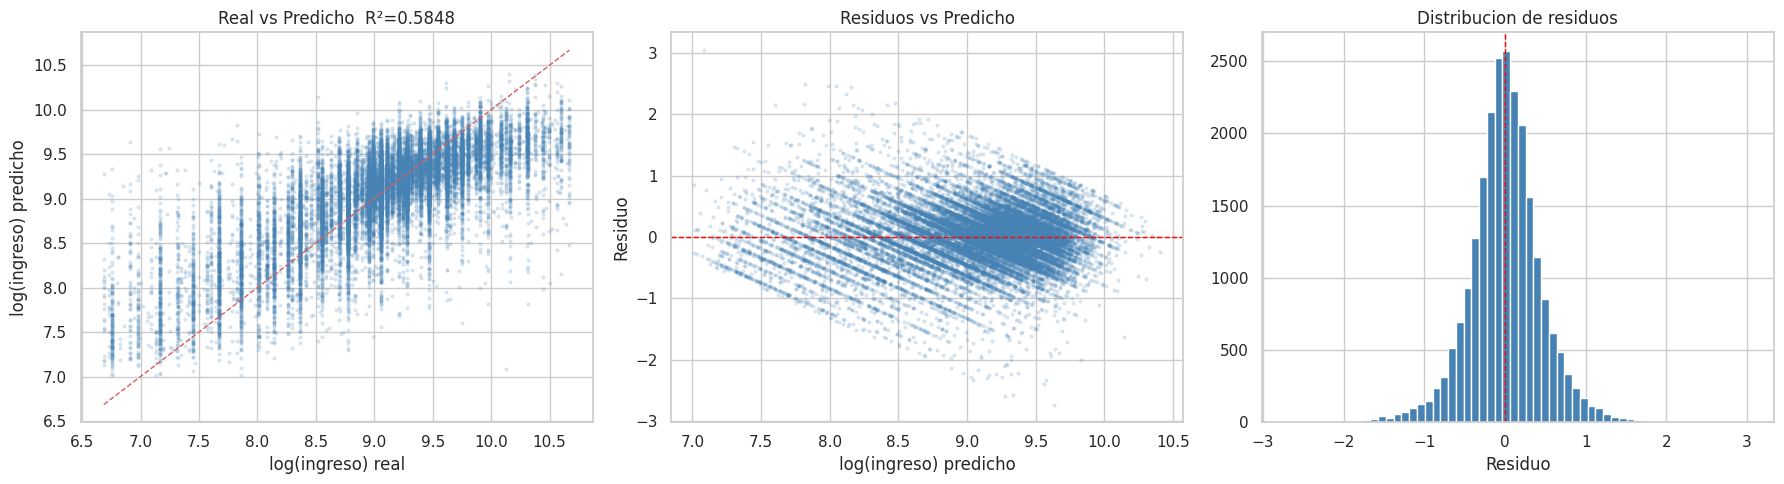

In [32]:
# Analisis de residuos M2
residuos  = y_test_m2 - y_pred_m2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real vs predicho
axes[0].scatter(y_test_m2, y_pred_m2, alpha=0.15, s=4, color='steelblue')
lims = [y_test_m2.min(), y_test_m2.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('log(ingreso) real')
axes[0].set_ylabel('log(ingreso) predicho')
axes[0].set_title(f'Real vs Predicho  R²={r2_m2:.4f}')

# Residuos vs predicho
axes[1].scatter(y_pred_m2, residuos, alpha=0.15, s=4, color='steelblue')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('log(ingreso) predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs Predicho')

# Distribucion de residuos
axes[2].hist(residuos, bins=60, color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linewidth=1, linestyle='--')
axes[2].set_xlabel('Residuo')
axes[2].set_title('Distribucion de residuos')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/m2_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Brecha salarial ajustada por entidad
# Construir perfil mediano por entidad y predecir para hombre y mujer
idx_mujer = FEATS_M2.index('es_mujer')

brecha_ajustada_lista = []
for ent in sorted(X_train_m2['cve_ent'].dropna().unique()):
    subset = X_train_m2[X_train_m2['cve_ent'] == ent]
    if len(subset) < 30:
        continue
    perfil_df = subset.median().to_frame().T

    perfil_h = perfil_df.copy(); perfil_h['es_mujer'] = 0
    perfil_m = perfil_df.copy(); perfil_m['es_mujer'] = 1

    ing_h = np.expm1(mejor_m2_pipe.predict(perfil_h)[0])
    ing_m = np.expm1(mejor_m2_pipe.predict(perfil_m)[0])
    brecha = round((ing_h - ing_m) / ing_h * 100, 2) if ing_h > 0 else np.nan

    brecha_ajustada_lista.append({
        'cve_ent'                 : int(ent),
        'ingreso_predicho_hombre' : round(ing_h, 2),
        'ingreso_predicho_mujer'  : round(ing_m, 2),
        'brecha_ajustada_pct'     : brecha
    })

brecha_ajustada = pd.DataFrame(brecha_ajustada_lista).sort_values('brecha_ajustada_pct', ascending=False)
display(brecha_ajustada)
brecha_ajustada.to_csv(f'{OUTPUT_DIR}/m2_brecha_ajustada_por_entidad.csv', index=False)

joblib.dump({'pipeline': mejor_m2_pipe, 'features': FEATS_M2},
            f'{OUTPUT_DIR}/modelo2_ingreso.joblib')
print('Modelo 2 guardado.')

,cve_ent,ingreso_predicho_hombre,ingreso_predicho_mujer,brecha_ajustada_pct
21,22,9846.9500,7345.4400,25.4000
0,1,9683.7100,7253.1600,25.1000
13,14,9906.1700,7465.7500,24.6400
23,24,9268.5300,6994.5400,24.5300
9,10,9014.7600,6814.4900,24.4100
10,11,9262.4500,7001.7200,24.4100
14,15,8385.3000,6359.2500,24.1600
31,32,9470.7400,7210.6000,23.8600
29,30,8260.4300,6290.6400,23.8500
15,16,8329.8800,6375.7800,23.4600


Modelo 2 guardado.


## 9. Modelo 3 — Informalidad laboral (clasificacion)

**Poblacion:** Personas ocupadas con condicion de formalidad registrada.
**Target:** `es_formal` (1=formal, 0=informal).

In [34]:
FEATS_M3_NUM = [c for c in (['experiencia', 'experiencia_sq', 'anios_esc', 'hrsocup']
                              if USAR_EXPERIENCIA else
                              ['eda', 'anios_esc', 'hrsocup'])
                if c not in VARS_EXCLUIR]
FEATS_M3_ORD = [c for c in ['niv_ins', 't_loc_tri'] if c not in VARS_EXCLUIR]
FEATS_M3_NOM = [c for c in ['scian', 'pos_ocu', 'e_con', 'cve_ent'] if c not in VARS_EXCLUIR]
FEATS_M3_BIN = ['es_mujer', 'ur']

FEATS_M3 = FEATS_M3_NUM + FEATS_M3_ORD + FEATS_M3_NOM + FEATS_M3_BIN
TARGET_M3 = 'es_formal'

# Agregar experiencia al df si se decidio usarla
if USAR_EXPERIENCIA and 'experiencia' not in raw.columns:
    raw['experiencia']    = (raw['eda'] - raw['anios_esc'] - 6).clip(lower=0)
    raw['experiencia_sq'] = raw['experiencia'] ** 2

df_m3 = raw[
    (raw['es_ocupado'] == 1) & (raw['emp_ppal'].notna())
][FEATS_M3 + [TARGET_M3]].dropna(subset=[TARGET_M3])

print(f'Dataset M3: {df_m3.shape}')
print(df_m3[TARGET_M3].value_counts(normalize=True).rename({0:'Informal',1:'Formal'}).mul(100).round(2))

Dataset M3: (190069, 13)
es_formal
Informal   51.9400
Formal     48.0600
Name: proportion, dtype: float64


In [35]:
X_m3 = df_m3[FEATS_M3]
y_m3 = df_m3[TARGET_M3].values

X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_m3, y_m3, test_size=0.2, random_state=RANDOM_STATE, stratify=y_m3
)

pre_num_m3 = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
pre_ord_m3 = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
pre_nom_m3 = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                        ('enc', TargetEncoder(random_state=RANDOM_STATE))])
pre_bin_m3 = SimpleImputer(strategy='median')

prepro_m3 = ColumnTransformer([
    ('num', pre_num_m3, FEATS_M3_NUM),
    ('ord', pre_ord_m3, FEATS_M3_ORD),
    ('nom', pre_nom_m3, FEATS_M3_NOM),
    ('bin', pre_bin_m3, FEATS_M3_BIN),
], remainder='drop')

# Baseline
pipe_base_m3 = Pipeline([('pre', prepro_m3),
                          ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
cv_m3_base = cross_val_score(
    pipe_base_m3, X_train_m3, y_train_m3,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

# GBM
pipe_gbm_m3 = Pipeline([('pre', prepro_m3),
                          ('clf', GradientBoostingClassifier(
                              n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, min_samples_leaf=20, random_state=RANDOM_STATE
                          ))])
cv_m3_gbm = cross_val_score(
    pipe_gbm_m3, X_train_m3, y_train_m3,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

# LightGBM
pipe_lgb_m3 = Pipeline([('pre', prepro_m3),
                          ('clf', lgb.LGBMClassifier(
                              n_estimators=500, max_depth=5, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8,
                              min_child_samples=20, random_state=RANDOM_STATE, verbose=-1
                          ))])
cv_m3_lgb = cross_val_score(
    pipe_lgb_m3, X_train_m3, y_train_m3,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

comp_m3 = pd.DataFrame({
    'modelo'       : ['Baseline (RegLog)', 'GradientBoosting', 'LightGBM'],
    'roc_auc_mean' : [cv_m3_base.mean(), cv_m3_gbm.mean(), cv_m3_lgb.mean()],
    'roc_auc_std'  : [cv_m3_base.std(),  cv_m3_gbm.std(),  cv_m3_lgb.std()]
})
display(comp_m3)

mejor_m3_nombre = comp_m3.loc[comp_m3['roc_auc_mean'].idxmax(), 'modelo']
mejor_m3_pipe   = {'Baseline (RegLog)': pipe_base_m3,
                   'GradientBoosting' : pipe_gbm_m3,
                   'LightGBM'         : pipe_lgb_m3}[mejor_m3_nombre]
print(f'\nMejor modelo M3: {mejor_m3_nombre}')

,modelo,roc_auc_mean,roc_auc_std
0,Baseline (RegLog),0.8698,0.0020
1,GradientBoosting,0.9038,0.0020
2,LightGBM,0.9065,0.0020



Mejor modelo M3: LightGBM


In [36]:
# Entrenamiento final M3
mejor_m3_pipe.fit(X_train_m3, y_train_m3)
y_pred_m3  = mejor_m3_pipe.predict(X_test_m3)
y_proba_m3 = mejor_m3_pipe.predict_proba(X_test_m3)[:, 1]

roc_m3 = roc_auc_score(y_test_m3, y_proba_m3)
print(f'=== M3 — Evaluacion en test ===')
print(f'ROC-AUC: {roc_m3:.4f}')
print(classification_report(y_test_m3, y_pred_m3, target_names=['Informal','Formal']))

# Riesgo de informalidad por sexo y sector para dashboard
X_m3_pred = X_train_m3.copy()
X_m3_pred['prob_informal'] = 1 - mejor_m3_pipe.predict_proba(X_m3_pred)[:, 1]
X_m3_pred['Sexo'] = X_m3_pred['es_mujer'].map({0: 'Hombre', 1: 'Mujer'})
riesgo_sector = (
    X_m3_pred.groupby(['scian', 'Sexo'])['prob_informal']
    .mean().mul(100).round(2).unstack('Sexo').reset_index()
)
display(riesgo_sector.head(10))
riesgo_sector.to_csv(f'{OUTPUT_DIR}/m3_riesgo_informalidad_sector.csv', index=False)

joblib.dump({'pipeline': mejor_m3_pipe, 'features': FEATS_M3},
            f'{OUTPUT_DIR}/modelo3_informalidad.joblib')
print('Modelo 3 guardado.')

=== M3 — Evaluacion en test ===
ROC-AUC: 0.9058
              precision    recall  f1-score   support

    Informal       0.85      0.82      0.83     19743
      Formal       0.81      0.84      0.82     18271

    accuracy                           0.83     38014
   macro avg       0.83      0.83      0.83     38014
weighted avg       0.83      0.83      0.83     38014



Sexo,scian,Hombre,Mujer
0,1.0000,83.1300,82.8800
1,2.0000,14.8400,9.8200
2,3.0000,11.5400,11.8000
3,4.0000,78.2500,47.7600
4,5.0000,30.9000,41.2800
5,6.0000,24.8000,25.4600
6,7.0000,53.2800,65.6500
7,8.0000,52.5300,34.2100
8,9.0000,13.6900,16.4800
9,10.0000,13.2800,15.7900


Modelo 3 guardado.


## 10. Resumen final de metricas

In [37]:
resumen_final = pd.DataFrame([
    {'modelo': 'M1 — Participacion laboral (mujeres)',
     'tipo': 'Clasificacion', 'algoritmo': mejor_m1_nombre,
     'metrica': 'ROC-AUC (test)', 'valor': round(roc_m1, 4)},
    {'modelo': 'M2 — Ingreso / Brecha salarial',
     'tipo': 'Regresion', 'algoritmo': mejor_m2_nombre,
     'metrica': 'R² (test)', 'valor': round(r2_m2, 4)},
    {'modelo': 'M3 — Informalidad laboral',
     'tipo': 'Clasificacion', 'algoritmo': mejor_m3_nombre,
     'metrica': 'ROC-AUC (test)', 'valor': round(roc_m3, 4)},
])
display(resumen_final)
resumen_final.to_csv(f'{OUTPUT_DIR}/resumen_metricas.csv', index=False)

print(f'\nArtefactos generados en {OUTPUT_DIR}/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

,modelo,tipo,algoritmo,metrica,valor
0,M1 — Participacion laboral (mujeres),Clasificacion,LightGBM,ROC-AUC (test),0.7907
1,M2 — Ingreso / Brecha salarial,Regresion,GradientBoosting,R² (test),0.5848
2,M3 — Informalidad laboral,Clasificacion,LightGBM,ROC-AUC (test),0.9058



Artefactos generados en artefactos_dashboard/
  brecha_salarial_bruta_por_entidad.csv
  eda_desigualdad.png
  m2_brecha_ajustada_por_entidad.csv
  m2_residuos.png
  m3_riesgo_informalidad_sector.csv
  missing_analisis.png
  modelo1_participacion.joblib
  modelo2_ingreso.joblib
  modelo3_informalidad.joblib
  participacion_femenina_por_entidad.csv
  resumen_metricas.csv


## 11. Funciones de inferencia para el dashboard

In [38]:
def predecir_participacion(edad, anios_esc, niv_ins, e_con,
                            n_hij, t_loc_tri, ur, cve_ent):
    art = joblib.load(f'{OUTPUT_DIR}/modelo1_participacion.joblib')
    X   = pd.DataFrame([dict(zip(art['features'],
                  [edad, anios_esc, niv_ins, e_con, n_hij, t_loc_tri, ur, cve_ent]))])
    return round(art['pipeline'].predict_proba(X)[0, 1] * 100, 2)


def predecir_brecha(edad, anios_esc, niv_ins, e_con, hrsocup,
                    scian, pos_ocu, t_loc_tri, ur, cve_ent):
    art = joblib.load(f'{OUTPUT_DIR}/modelo2_ingreso.joblib')
    base = dict(zip(art['features'], [0] * len(art['features'])))
    for k, v in zip(['eda' if not USAR_EXPERIENCIA else 'experiencia',
                     'anios_esc', 'niv_ins', 'e_con', 'hrsocup',
                     'scian', 'pos_ocu', 't_loc_tri', 'ur', 'cve_ent'],
                    [edad, anios_esc, niv_ins, e_con, hrsocup,
                     scian, pos_ocu, t_loc_tri, ur, cve_ent]):
        if k in base:
            base[k] = v
    if USAR_EXPERIENCIA and 'experiencia_sq' in base:
        base['experiencia_sq'] = base.get('experiencia', 0) ** 2

    ph = pd.DataFrame([{**base, 'es_mujer': 0}])[art['features']]
    pm = pd.DataFrame([{**base, 'es_mujer': 1}])[art['features']]
    ing_h = np.expm1(art['pipeline'].predict(ph)[0])
    ing_m = np.expm1(art['pipeline'].predict(pm)[0])
    brecha = round((ing_h - ing_m) / ing_h * 100, 2) if ing_h > 0 else None
    return {'ingreso_hombre': round(ing_h, 2),
            'ingreso_mujer' : round(ing_m, 2),
            'brecha_pct'    : brecha}


def predecir_informalidad(es_mujer, edad, anios_esc, niv_ins, e_con,
                           hrsocup, scian, pos_ocu, t_loc_tri, ur, cve_ent):
    art = joblib.load(f'{OUTPUT_DIR}/modelo3_informalidad.joblib')
    vals = dict(zip(['eda' if not USAR_EXPERIENCIA else 'experiencia',
                     'anios_esc', 'niv_ins', 'e_con', 'hrsocup',
                     'scian', 'pos_ocu', 't_loc_tri', 'ur', 'cve_ent', 'es_mujer'],
                    [edad, anios_esc, niv_ins, e_con, hrsocup,
                     scian, pos_ocu, t_loc_tri, ur, cve_ent, es_mujer]))
    if USAR_EXPERIENCIA and 'experiencia_sq' in art['features']:
        vals['experiencia_sq'] = vals.get('experiencia', 0) ** 2
    X = pd.DataFrame([vals])[art['features']]
    return round((1 - art['pipeline'].predict_proba(X)[0, 1]) * 100, 2)


# Prueba de las tres funciones
print('--- M1: Probabilidad de participar (mujer, 30a, secundaria, casada, 2 hijos, rural, Oaxaca) ---')
print(predecir_participacion(30, 9, 3, 5, 2, 4, 2, 20), '%')

print('\n--- M2: Brecha (35a, licenciatura, comercio, CDMX, 40hrs) ---')
print(predecir_brecha(35, 16, 4, 5, 40, 7, 1, 1, 1, 9))

print('\n--- M3: Probabilidad de informalidad (mujer, 25a, preparatoria, comercio, rural) ---')
print(predecir_informalidad(1, 25, 12, 4, 1, 30, 7, 3, 4, 2, 20), '%')

--- M1: Probabilidad de participar (mujer, 30a, secundaria, casada, 2 hijos, rural, Oaxaca) ---
6.8 %

--- M2: Brecha (35a, licenciatura, comercio, CDMX, 40hrs) ---
{'ingreso_hombre': np.float64(18423.79), 'ingreso_mujer': np.float64(15238.93), 'brecha_pct': np.float64(17.29)}

--- M3: Probabilidad de informalidad (mujer, 25a, preparatoria, comercio, rural) ---
96.29 %
